# Prediksi Harga Cabai Rawit Kota Bandung dengan CatBoost
**Dataset:** Harga Harian Cabai Rawit + Variabel Iklim Open-Meteo (2022–2026)  
**Metode:** CatBoost Regressor + Optuna (Bayesian Optimization) + Early Stopping  
**Split:** 80% Train : 20% Test (kronologis)


## 1. Instalasi Library

In [1]:
!pip install catboost optuna openmeteo-requests requests-cache retry-requests -q



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\rizal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Import Library

In [2]:
import warnings, calendar, joblib
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

import openmeteo_requests, requests_cache
from retry_requests import retry

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\rizal\anaconda3\envs\catboost_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Business Understanding

Harga cabai rawit sangat fluktuatif dan berdampak langsung pada inflasi pangan. Penelitian ini membangun model prediksi harga harian cabai rawit di Kota Bandung menggunakan data historis harga dan variabel iklim, dengan harapan dapat membantu pedagang, dinas perdagangan, dan konsumen dalam mengantisipasi lonjakan harga.

**Pertanyaan Riset:**
1. Pada jeda waktu (*lag*) berapa variabel iklim berkorelasi paling kuat terhadap harga cabai rawit?
2. Seberapa akurat model CatBoost dalam memprediksi harga cabai rawit harian?
3. Apakah variabel iklim benar-benar memberikan kontribusi terhadap akurasi prediksi?


## 4. Data Understanding

In [3]:
df = pd.read_excel('dataset harga cabai rawit pasar tradisional dan iklim kota bandung.xlsx')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)
df.head()

,Tanggal,Harga Cabai Rawit (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm)
0,2022-01-03,86000,28.4,16.0,22.8,0.0,0,8.9,26.20,5.19
1,2022-01-04,86000,27.8,17.6,22.8,0.3,2,13.8,24.12,4.72
2,2022-01-05,86000,28.0,19.3,23.1,3.9,7,14.1,24.28,4.72
3,2022-01-06,70000,27.5,19.4,22.7,3.8,7,12.5,19.56,3.71
4,2022-01-07,70000,26.5,20.0,22.3,9.1,10,12.1,16.41,3.18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578 entries, 0 to 1577
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Tanggal                      1578 non-null   datetime64[ns]
 1   Harga Cabai Rawit (Rp/kg)    1578 non-null   int64         
 2   Suhu Max (°C)                1578 non-null   float64       
 3   Suhu Min (°C)                1578 non-null   float64       
 4   Suhu Mean (°C)               1578 non-null   float64       
 5   Curah Hujan (mm)             1578 non-null   float64       
 6   Durasi Hujan (jam)           1578 non-null   int64         
 7   Kecepatan Angin Maks (km/h)  1578 non-null   float64       
 8   Radiasi Matahari (MJ/m²)     1578 non-null   float64       
 9   Evapotranspirasi ET0 (mm)    1578 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 123.4 KB


In [5]:
df.describe().round(2)

,Tanggal,Harga Cabai Rawit (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm)
count,1578,1578.00,1578.0,1578.00,1578.00,1578.00,1578.00,1578.00,1578.00,1578.00
mean,2024-03-01 11:59:59.999999744,48847.43,28.0,19.06,23.02,5.76,6.76,11.63,18.88,3.80
min,2022-01-03 00:00:00,21000.00,22.0,13.90,19.90,0.00,0.00,5.10,4.84,1.08
25%,2023-02-01 06:00:00,34000.00,27.0,18.20,22.40,0.40,2.00,9.40,16.31,3.22
50%,2024-03-01 12:00:00,43500.00,28.0,19.10,23.00,2.20,6.00,11.00,19.05,3.79
75%,2025-03-30 18:00:00,63750.00,29.0,20.10,23.58,8.07,10.00,13.50,21.60,4.33
max,2026-04-29 00:00:00,97500.00,33.3,22.20,26.10,68.40,24.00,24.90,27.78,6.33
std,NaN,19688.25,1.7,1.41,0.87,8.39,5.31,3.17,4.01,0.87


### 4.1 Tren Harga Cabai Rawit (2022–2026)

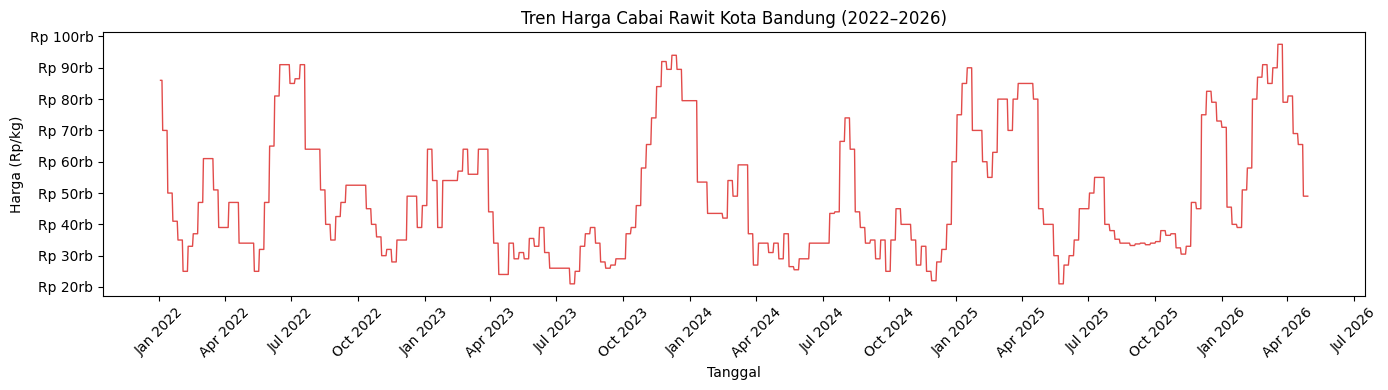

In [6]:
plt.figure(figsize=(14, 4))
plt.plot(df['Tanggal'], df['Harga Cabai Rawit (Rp/kg)'], color='#E24B4A', linewidth=1)
plt.title('Tren Harga Cabai Rawit Kota Bandung (2022–2026)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp/kg)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}rb'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Rata-rata Harga per Bulan dan Tahun

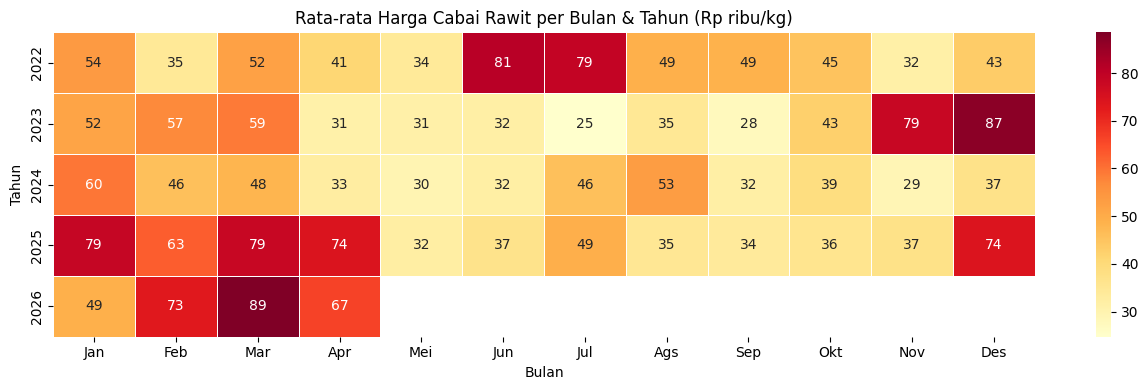

In [7]:
BULAN = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
pivot = df.pivot_table(
    values='Harga Cabai Rawit (Rp/kg)',
    index=df['Tanggal'].dt.year,
    columns=df['Tanggal'].dt.month,
    aggfunc='mean'
) / 1000

plt.figure(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=BULAN, linewidths=0.5)
plt.title('Rata-rata Harga Cabai Rawit per Bulan & Tahun (Rp ribu/kg)')
plt.xlabel('Bulan'); plt.ylabel('Tahun')
plt.tight_layout()
plt.show()

### 4.3 Distribusi Variabel Iklim

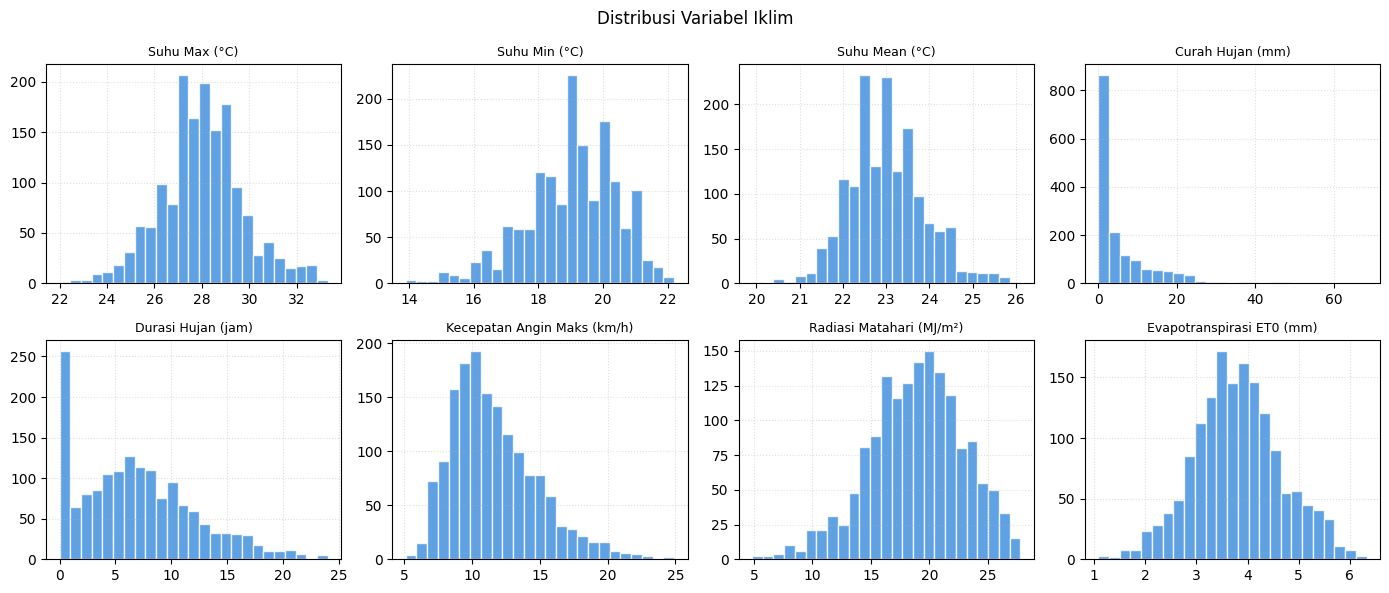

In [8]:
kolom_iklim = [
    'Suhu Max (°C)', 'Suhu Min (°C)', 'Suhu Mean (°C)',
    'Curah Hujan (mm)', 'Durasi Hujan (jam)',
    'Kecepatan Angin Maks (km/h)', 'Radiasi Matahari (MJ/m²)',
    'Evapotranspirasi ET0 (mm)'
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flatten(), kolom_iklim):
    ax.hist(df[col].dropna(), bins=25, color='#378ADD', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.4)
plt.suptitle('Distribusi Variabel Iklim', fontsize=12)
plt.tight_layout()
plt.show()

### 4.4 Korelasi Variabel Iklim

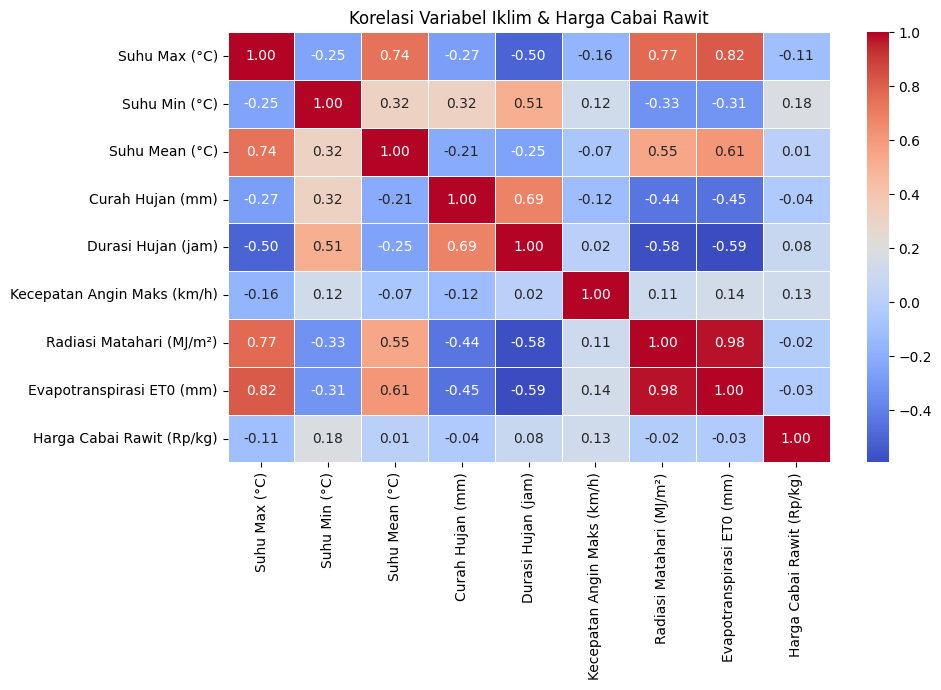

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[kolom_iklim + ['Harga Cabai Rawit (Rp/kg)']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Variabel Iklim & Harga Cabai Rawit')
plt.tight_layout()
plt.show()

### 4.5 Lag Correlation Analysis

Dalam sektor pertanian, gangguan iklim tidak langsung berdampak pada harga. Tanaman membutuhkan waktu untuk merespons perubahan cuaca, sehingga efek iklim baru terlihat pada harga beberapa hari hingga minggu kemudian. Analisis lag correlation mengukur korelasi variabel iklim beberapa hari sebelumnya terhadap harga hari ini.


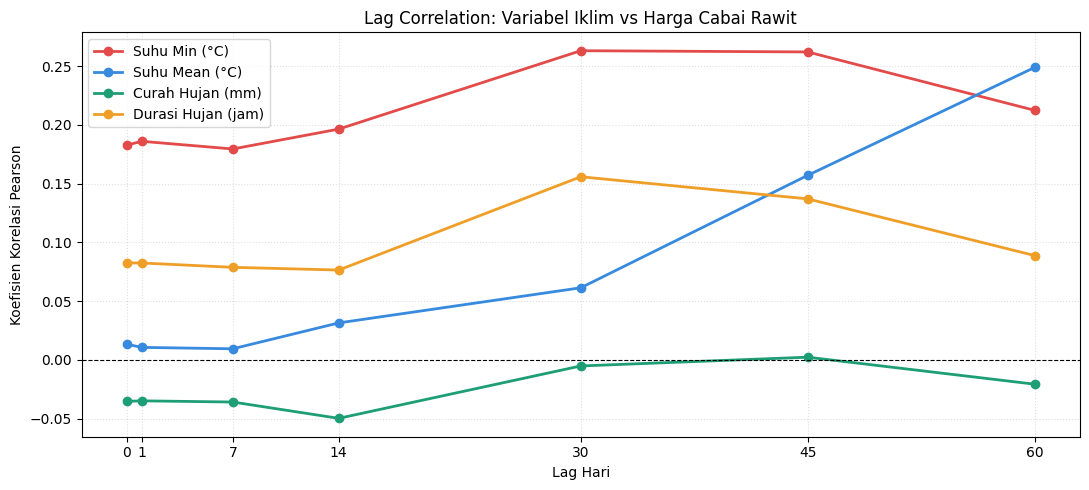

In [10]:
lags = [0, 1, 7, 14, 30, 45, 60]
kolom_uji  = ['Suhu Min (°C)', 'Suhu Mean (°C)', 'Curah Hujan (mm)', 'Durasi Hujan (jam)']
warna      = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27']

lag_corr = {col: [df['Harga Cabai Rawit (Rp/kg)'].corr(df[col].shift(l)) for l in lags]
            for col in kolom_uji}

plt.figure(figsize=(11, 5))
for col, w in zip(kolom_uji, warna):
    plt.plot(lags, lag_corr[col], marker='o', label=col, color=w, linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Lag Correlation: Variabel Iklim vs Harga Cabai Rawit')
plt.xlabel('Lag Hari'); plt.ylabel('Koefisien Korelasi Pearson')
plt.xticks(lags); plt.legend(); plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
pd.DataFrame(lag_corr, index=[f'lag_{l}' for l in lags]).round(4)

,Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam)
lag_0,0.1828,0.0133,-0.0353,0.0825
lag_1,0.1860,0.0106,-0.0349,0.0824
lag_7,0.1795,0.0094,-0.0359,0.0787
lag_14,0.1964,0.0314,-0.0498,0.0764
lag_30,0.2631,0.0613,-0.0052,0.1558
lag_45,0.2620,0.1570,0.0023,0.1370
lag_60,0.2124,0.2488,-0.0207,0.0888


**Interpretasi:**

Suhu minimum menunjukkan korelasi positif yang meningkat seiring jeda waktu, mencapai puncaknya pada lag 45–60 hari. Pola ini mencerminkan *time-lag effect* pada siklus pertanian cabai rawit, di mana kondisi suhu rendah yang dialami tanaman selama fase pembungaan dan pembuahan berdampak pada kualitas dan volume panen 45–60 hari kemudian, yang pada akhirnya mempengaruhi harga di pasar.


## 5. Data Preparation & Feature Engineering

In [12]:
harga = df['Harga Cabai Rawit (Rp/kg)']
for l in [1, 2, 3, 5, 7, 14, 30]:
    df[f'lag_{l}'] = harga.shift(l)

deltas = {'delta_1_3': (1,3), 'delta_1_7': (1,7), 'delta_7_14': (7,14), 'delta_7_30': (7,30), 'momentum_5': (1,5)}
for nama, (a, b) in deltas.items():
    df[nama] = df[f'lag_{a}'] - df[f'lag_{b}']

for w in [7, 14, 30]:
    df[f'SuhuMin_rolling_{w}']    = df['Suhu Min (°C)'].rolling(w).mean()
    df[f'CurahHujan_rolling_{w}'] = df['Curah Hujan (mm)'].rolling(w).mean()
for l in [7, 14, 21, 30, 45, 60]:
    df[f'SuhuMin_lag_{l}'] = df['Suhu Min (°C)'].shift(l)

df['CurahHujan_cum_14'] = df['Curah Hujan (mm)'].rolling(14).sum()
df['CurahHujan_cum_30'] = df['Curah Hujan (mm)'].rolling(30).sum()

df['bulan'], df['tahun'] = df['Tanggal'].dt.month, df['Tanggal'].dt.year
TANGGAL_AWAL = df['Tanggal'].min()
df['hari_index']   = (df['Tanggal'] - TANGGAL_AWAL).dt.days
df['target_delta'] = harga - df['lag_1']   # target = delta, bukan harga mentah

df_model = df.dropna().reset_index(drop=True)
print(f'Total data: {len(df_model)} baris')
df_model.head()

Total data: 1518 baris


,Tanggal,Harga Cabai Rawit (Rp/kg),Suhu Max (°C),Suhu Min (°C),Suhu Mean (°C),Curah Hujan (mm),Durasi Hujan (jam),Kecepatan Angin Maks (km/h),Radiasi Matahari (MJ/m²),Evapotranspirasi ET0 (mm),...,SuhuMin_lag_21,SuhuMin_lag_30,SuhuMin_lag_45,SuhuMin_lag_60,CurahHujan_cum_14,CurahHujan_cum_30,bulan,tahun,hari_index,target_delta
0,2022-03-04,61000,27.1,20.4,23.0,22.4,17,12.3,18.21,3.63,...,19.5,18.5,19.8,16.0,58.1,170.1,3,2022,60,0.0
1,2022-03-05,61000,27.1,20.4,23.0,22.4,17,12.3,18.21,3.63,...,19.5,19.4,20.4,17.6,70.6,180.1,3,2022,61,0.0
2,2022-03-06,61000,27.1,20.4,23.0,22.4,17,12.3,18.21,3.63,...,19.5,19.0,18.5,19.3,83.1,196.5,3,2022,62,0.0
3,2022-03-07,61000,26.6,18.7,22.6,3.3,10,11.2,11.22,2.39,...,20.1,19.0,19.0,19.4,86.4,193.8,3,2022,63,0.0
4,2022-03-08,61000,27.1,17.9,22.3,2.6,7,11.0,16.74,3.35,...,18.9,19.0,19.0,20.0,88.0,190.4,3,2022,64,0.0


In [13]:
momentum_cols = ['lag_2','lag_3','lag_5','lag_7','lag_14','lag_30',
                  'delta_1_3','delta_1_7','delta_7_14','delta_7_30','momentum_5']
iklim_cols = ['Suhu Max (°C)','Suhu Min (°C)','Suhu Mean (°C)','Curah Hujan (mm)','Durasi Hujan (jam)',
              'Kecepatan Angin Maks (km/h)','Radiasi Matahari (MJ/m²)','Evapotranspirasi ET0 (mm)',
              'SuhuMin_rolling_7','SuhuMin_rolling_14','SuhuMin_rolling_30',
              'CurahHujan_rolling_7','CurahHujan_rolling_14','CurahHujan_rolling_30',
              'SuhuMin_lag_7','SuhuMin_lag_14','SuhuMin_lag_21','SuhuMin_lag_30','SuhuMin_lag_45','SuhuMin_lag_60',
              'CurahHujan_cum_14','CurahHujan_cum_30']
waktu_cols = ['bulan', 'tahun', 'hari_index']
fitur, target = momentum_cols + iklim_cols + waktu_cols, 'target_delta'   # lag_1 TIDAK termasuk fitur

X, y = df_model[fitur], df_model[target]
harga_aktual, lag1_all = df_model['Harga Cabai Rawit (Rp/kg)'], df_model['lag_1']

split_idx = int(len(df_model) * 0.8)   # split kronologis 80:20
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
harga_test_aktual = harga_aktual.iloc[split_idx:].reset_index(drop=True)
lag1_test         = lag1_all.iloc[split_idx:].reset_index(drop=True)

print(f'Data latih: {len(X_train)} | Data uji: {len(X_test)} (mulai {df_model["Tanggal"].iloc[split_idx].date()})')

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Data latih: 1214 | Data uji: 304 (mulai 2025-06-30)


## 6. Modeling

### 6.1 Hyperparameter Tuning (Optuna — Bayesian Optimization)

Tuning menggunakan **Optuna** (TPE Sampler), yang mencari kombinasi hyperparameter secara adaptif berdasarkan hasil percobaan sebelumnya — berbeda dengan Grid Search yang mencoba semua kombinasi grid diskrit secara brute-force. Pendekatan ini memungkinkan eksplorasi rentang nilai kontinu dan biasanya menemukan kombinasi lebih optimal dengan jumlah percobaan (*trial*) yang lebih sedikit.

| Hyperparameter | Rentang Dicoba |
|---|---|
| `learning_rate` | 0.005 – 0.3 (skala log) |
| `depth` | 2 – 8 |
| `iterations` | 50 – 400 |
| `l2_leaf_reg` | 0.01 – 30 (skala log) |
| `random_strength` | 0.001 – 10 (skala log) |
| `bagging_temperature` | 0.0 – 3.0 |
| `border_count` | 32 – 255 |

Evaluasi tiap trial menggunakan **TimeSeriesSplit** (3-fold) agar validasi tetap menghormati urutan waktu (tidak ada kebocoran data dari masa depan ke masa lalu).


In [14]:
def objective(trial):
    params = {
        'learning_rate'      : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'depth'              : trial.suggest_int('depth', 2, 8),
        'iterations'         : trial.suggest_int('iterations', 50, 400),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg', 1e-2, 30, log=True),
        'random_strength'    : trial.suggest_float('random_strength', 1e-3, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),
        'border_count'       : trial.suggest_int('border_count', 32, 255),
    }
    tscv = TimeSeriesSplit(n_splits=3)
    maes = []
    for tr_idx, val_idx in tscv.split(X_train_scaled):
        m = CatBoostRegressor(**params, loss_function='RMSE', random_seed=42, verbose=0)
        m.fit(X_train_scaled[tr_idx], y_train.values[tr_idx])
        pred = m.predict(X_train_scaled[val_idx])
        maes.append(mean_absolute_error(y_train.values[val_idx], pred))
    return float(np.mean(maes))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, timeout=200, show_progress_bar=False)

best = study.best_params
print('Parameter Optuna :', best)
print(f'MAE CV terbaik (pada delta) : Rp {study.best_value:,.0f}/kg')


Parameter Optuna : {'learning_rate': 0.00513239564377715, 'depth': 8, 'iterations': 398, 'l2_leaf_reg': 28.755487319371685, 'random_strength': 0.00938894305700229, 'bagging_temperature': 1.7569532162901074, 'border_count': 193}
MAE CV terbaik (pada delta) : Rp 1,018/kg


### 6.2 Training Model CatBoost

In [15]:
model = CatBoostRegressor(
    **best,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)
model.fit(X_train_scaled, y_train, eval_set=(X_test_scaled, y_test))


0:	learn: 3328.6779569	test: 3562.1510191	best: 3562.1510191 (0)	total: 9ms	remaining: 3.57s
100:	learn: 3249.0402958	test: 3518.0251089	best: 3518.0251089 (100)	total: 548ms	remaining: 1.61s
200:	learn: 3176.7660106	test: 3488.4743246	best: 3488.4743246 (200)	total: 1.09s	remaining: 1.07s
300:	learn: 3110.8167210	test: 3461.7972136	best: 3461.7932492 (299)	total: 1.61s	remaining: 518ms
397:	learn: 3067.5663751	test: 3447.7367511	best: 3447.7207025 (394)	total: 2.11s	remaining: 0us

bestTest = 3447.720702
bestIteration = 394

Shrink model to first 395 iterations.


CatBoostRegressor(bagging_temperature=1.7569532162901074, border_count=193, depth=8, early_stopping_rounds=50, eval_metric='RMSE', iterations=398, l2_leaf_reg=28.755487319371685, learning_rate=0.00513239564377715, loss_function='RMSE', random_seed=42, random_strength=0.00938894305700229, verbose=100)

## 7. Evaluasi Model

### 7.1 Evaluasi Kuantitatif

Model memprediksi **delta harga**, sehingga harga akhir direkonstruksi dengan `harga_prediksi = lag_1 + delta_prediksi`.

---

In [16]:
delta_pred = model.predict(X_test_scaled)
y_pred     = lag1_test.values + delta_pred          # rekonstruksi harga dari delta

def hitung_metrik(y_true, y_hat):
    return {
        'MAE (Rp)' : round(mean_absolute_error(y_true, y_hat), 2),
        'RMSE (Rp)': round(np.sqrt(mean_squared_error(y_true, y_hat)), 2),
        'R2 Score' : round(r2_score(y_true, y_hat), 4),
        'MAPE (%)' : round(mean_absolute_percentage_error(y_true, y_hat) * 100, 2)
    }

evaluasi = pd.DataFrame([
    {'Model': 'CatBoost', **hitung_metrik(harga_test_aktual.values, y_pred)}
])
evaluasi

,Model,MAE (Rp),RMSE (Rp),R2 Score,MAPE (%)
0,CatBoost,936.22,3447.72,0.9722,1.65


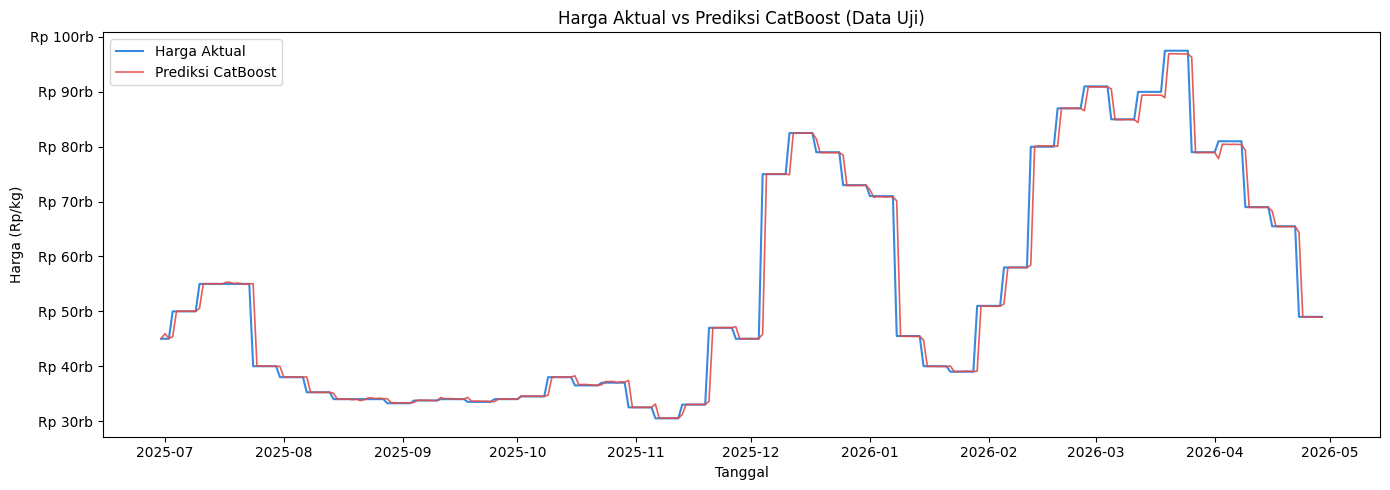

In [17]:
test_dates = df_model['Tanggal'].iloc[split_idx:].values

plt.figure(figsize=(14, 5))
plt.plot(test_dates, harga_test_aktual.values, label='Harga Aktual', color='#378ADD', linewidth=1.5)
plt.plot(test_dates, y_pred, label='Prediksi CatBoost', color='#E24B4A', linewidth=1.2, alpha=0.9)
plt.title('Harga Aktual vs Prediksi CatBoost (Data Uji)')
plt.xlabel('Tanggal'); plt.ylabel('Harga (Rp/kg)')
plt.legend(loc='upper left')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}rb'))
plt.tight_layout()
plt.show()

### 7.4 Tabel Hasil Prediksi

In [18]:
df_hasil = pd.DataFrame({
    'Tanggal'          : pd.to_datetime(test_dates).strftime('%d/%m/%Y'),
    'Harga Aktual'     : harga_test_aktual.values,
    'Harga Prediksi'   : y_pred.round(0),
    'Error (Rp)'       : np.abs(harga_test_aktual.values - y_pred).round(0)
})
df_hasil.head(10)

,Tanggal,Harga Aktual,Harga Prediksi,Error (Rp)
0,30/06/2025,45000,45066.0,66.0
1,01/07/2025,45000,45930.0,930.0
2,02/07/2025,45000,45111.0,111.0
3,03/07/2025,50000,45367.0,4633.0
4,04/07/2025,50000,50023.0,23.0
5,05/07/2025,50000,50024.0,24.0
6,06/07/2025,50000,50025.0,25.0
7,07/07/2025,50000,50017.0,17.0
8,08/07/2025,50000,50010.0,10.0
9,09/07/2025,50000,50014.0,14.0


### 7.5 Residual Analysis

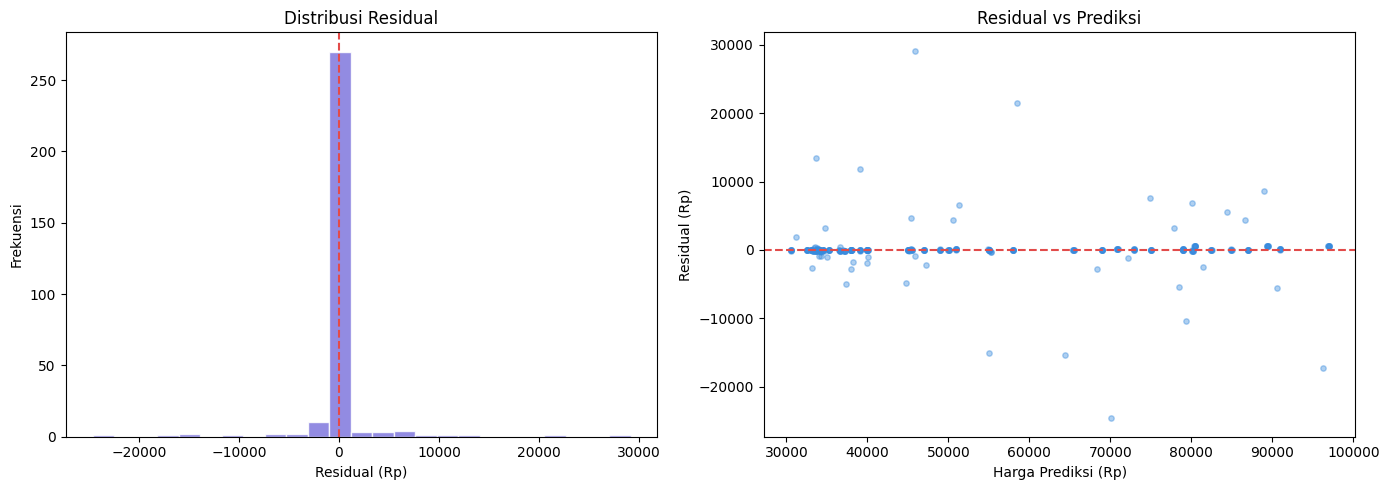

Rata-rata residual : Rp 54.47
Std residual        : Rp 3,447.29


In [19]:
residual = harga_test_aktual.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residual, bins=25, color='#7F77DD', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='#E24B4A', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribusi Residual')
axes[0].set_xlabel('Residual (Rp)'); axes[0].set_ylabel('Frekuensi')

axes[1].scatter(y_pred, residual, alpha=0.4, color='#378ADD', s=15)
axes[1].axhline(0, color='#E24B4A', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual vs Prediksi')
axes[1].set_xlabel('Harga Prediksi (Rp)'); axes[1].set_ylabel('Residual (Rp)')

plt.tight_layout()
plt.show()

print(f'Rata-rata residual : Rp {residual.mean():,.2f}')
print(f'Std residual        : Rp {residual.std():,.2f}')


**Interpretasi:**

Residual positif berarti model *underestimate* (prediksi < aktual), negatif berarti *overestimate*. Rata-rata residual yang mendekati nol menunjukkan tidak ada bias sistematis pada model.



### 7.6 Feature Importance

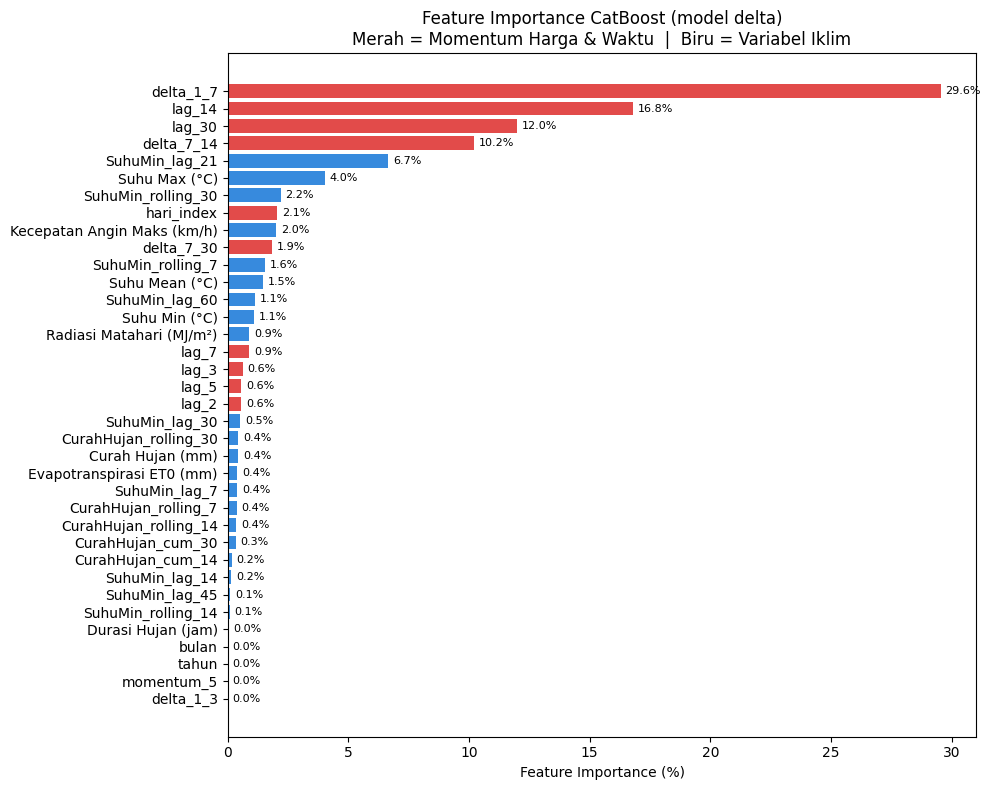

In [20]:
importance = model.get_feature_importance()
feat_df = pd.DataFrame({'Fitur': fitur, 'Importance': importance}).sort_values('Importance', ascending=True)

MOMENTUM = set(momentum_cols) | {'bulan', 'tahun', 'hari_index'}
colors = ['#E24B4A' if f in MOMENTUM else '#378ADD' for f in feat_df['Fitur']]

plt.figure(figsize=(10, 8))
bars = plt.barh(feat_df['Fitur'], feat_df['Importance'], color=colors)
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8)
plt.xlabel('Feature Importance (%)')
plt.title('Feature Importance CatBoost (model delta)\nMerah = Momentum Harga & Waktu  |  Biru = Variabel Iklim')
plt.tight_layout()
plt.show()


## 8. Deployment

### 8.1 Simpan Model

In [21]:
model.save_model('model_catboost_cabai.cbm')
joblib.dump(scaler, 'scaler_cabai.pkl')
joblib.dump(fitur,  'fitur_cabai.pkl')
print('Model, scaler, dan daftar fitur berhasil disimpan.')
print('Catatan: model memprediksi DELTA harga. Saat inference, harga akhir = lag_1 + delta_prediksi.')


Model, scaler, dan daftar fitur berhasil disimpan.
Catatan: model memprediksi DELTA harga. Saat inference, harga akhir = lag_1 + delta_prediksi.


### 8.2 Prediksi Harga Bulanan

Sistem mengambil data iklim dari **API Open-Meteo** secara otomatis. Jika API tidak tersedia (bulan mendatang), digunakan **estimasi rata-rata historis** bulan yang sama dari tahun-tahun sebelumnya.


In [22]:
NAMA_BULAN = {
    1:'Januari', 2:'Februari', 3:'Maret',  4:'April',
    5:'Mei',     6:'Juni',     7:'Juli',   8:'Agustus',
    9:'September', 10:'Oktober', 11:'November', 12:'Desember'
}

print('Pilih bulan untuk prediksi:')
for k, v in NAMA_BULAN.items():
    print(f'  {k:>2}. {v}')

bulan = int(input('\nMasukkan nomor bulan : '))
tahun = int(input('Masukkan tahun       : '))
print(f'\nPrediksi untuk: {NAMA_BULAN[bulan]} {tahun}')

Pilih bulan untuk prediksi:
   1. Januari
   2. Februari
   3. Maret
   4. April
   5. Mei
   6. Juni
   7. Juli
   8. Agustus
   9. September
  10. Oktober
  11. November
  12. Desember

Prediksi untuk: Juli 2027


In [23]:
LAT, LON  = -6.9175, 107.6191
COL_IKLIM = ['Suhu Max (°C)', 'Suhu Min (°C)', 'Suhu Mean (°C)', 'Curah Hujan (mm)',
             'Durasi Hujan (jam)', 'Kecepatan Angin Maks (km/h)',
             'Radiasi Matahari (MJ/m²)', 'Evapotranspirasi ET0 (mm)']

# Tentukan rentang tanggal untuk bulan & tahun yang dipilih
last_day   = calendar.monthrange(tahun, bulan)[1]
start_date = date(tahun, bulan, 1)
end_date   = date(tahun, bulan, last_day)

# Kalau tanggalnya sudah lewat, pakai API arsip. Kalau belum, pakai API forecast.
if end_date < date.today():
    url = 'https://archive-api.open-meteo.com/v1/archive'
else:
    url = 'https://api.open-meteo.com/v1/forecast'

params = {
    'latitude': LAT, 'longitude': LON, 'timezone': 'Asia/Jakarta',
    'start_date': str(start_date), 'end_date': str(end_date),
    'daily': ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
              'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max',
              'shortwave_radiation_sum', 'et0_fao_evapotranspiration']
}

try:
    # --- Coba ambil data iklim asli dari API Open-Meteo ---
    session = requests_cache.CachedSession('.cache', expire_after=3600)
    client  = openmeteo_requests.Client(session=retry(session, retries=5, backoff_factor=0.2))
    daily   = client.weather_api(url, params=params)[0].Daily()

    tanggal_range = pd.date_range(str(start_date), str(end_date), freq='D')
    df_iklim = pd.DataFrame({'Tanggal': tanggal_range})
    for i, kolom in enumerate(COL_IKLIM):
        df_iklim[kolom] = daily.Variables(i).ValuesAsNumpy()
    df_iklim['bulan'] = df_iklim['Tanggal'].dt.month

    SUMBER = 'API Real (Open-Meteo)'
    print(f'Data iklim dari API: {len(df_iklim)} hari')

except Exception:
    # --- Fallback: rata-rata historis per tanggal, disesuaikan tren tahunan ---
    df_hist = df[df['Tanggal'].dt.month == bulan]
    rata_per_tanggal = df_hist.groupby(df_hist['Tanggal'].dt.day)[COL_IKLIM].mean()
    rata_per_tahun   = df_hist.groupby(df_hist['Tanggal'].dt.year)[COL_IKLIM].mean()

    # Hitung offset tren tahunan untuk tiap variabel iklim, supaya tahun berbeda -> nilai berbeda
    offset = {}
    for kolom in COL_IKLIM:
        data_tahunan = rata_per_tahun[kolom].dropna()
        if len(data_tahunan) >= 2:
            slope = np.polyfit(data_tahunan.index, data_tahunan.values, 1)[0]
            offset[kolom] = slope * (tahun - np.mean(data_tahunan.index))
        else:
            offset[kolom] = 0.0

    rata_disesuaikan = rata_per_tanggal + pd.Series(offset)

    tanggal_range = pd.date_range(str(start_date), str(end_date), freq='D')
    df_iklim = pd.DataFrame({'hari': tanggal_range.day})
    df_iklim = df_iklim.merge(rata_disesuaikan.reset_index().rename(columns={'Tanggal': 'hari'}),
                               on='hari', how='left')
    df_iklim = df_iklim.fillna(rata_disesuaikan.mean()).drop(columns='hari')
    df_iklim['Tanggal'] = tanggal_range
    df_iklim['bulan']   = bulan

    SUMBER = 'Estimasi Historis + Tren Tahunan'
    teks_offset = ', '.join(f'{k}={v:+.2f}' for k, v in offset.items())
    print(f'Estimasi iklim: {len(df_iklim)} hari (offset tahun {tahun}: {teks_offset})')

df_iklim['tahun']      = df_iklim['Tanggal'].dt.year
df_iklim['hari_index'] = (df_iklim['Tanggal'] - TANGGAL_AWAL).dt.days

MODE = 'EVALUASI' if df['Tanggal'].between(str(start_date), str(end_date)).any() else 'PREDIKSI'
print(f'Mode: {MODE} | Sumber iklim: {SUMBER}')


Estimasi iklim: 31 hari (offset tahun 2027: Suhu Max (°C)=+0.07, Suhu Min (°C)=+0.33, Suhu Mean (°C)=+0.23, Curah Hujan (mm)=+0.27, Durasi Hujan (jam)=-0.60, Kecepatan Angin Maks (km/h)=-0.32, Radiasi Matahari (MJ/m²)=+0.48, Evapotranspirasi ET0 (mm)=+0.12)
Mode: PREDIKSI | Sumber iklim: Estimasi Historis + Tren Tahunan


In [24]:
# Kumpulan data historis (dipakai sebagai "memori" model saat prediksi maju ke depan)
aktual_dict = df.set_index(df['Tanggal'].dt.date)['Harga Cabai Rawit (Rp/kg)'].to_dict()
harga_buf = list(df[df['Tanggal'] < pd.Timestamp(start_date)]['Harga Cabai Rawit (Rp/kg)'].values)
suhu_buf  = list(df[df['Tanggal'] < pd.Timestamp(start_date)]['Suhu Min (°C)'].values)
hujan_buf = list(df[df['Tanggal'] < pd.Timestamp(start_date)]['Curah Hujan (mm)'].values)


def ambil_lag(buffer, n):
    """Ambil nilai n hari ke belakang dari buffer."""
    if len(buffer) >= n:
        return buffer[-n]
    return buffer[0]


def rata_rata_bergerak(buffer, window):
    """Rata-rata bergerak (rolling mean) dari 'window' hari terakhir di buffer."""
    return float(np.mean(buffer[-window:]))


def total_bergerak(buffer, window):
    """Total kumulatif (rolling sum) dari 'window' hari terakhir di buffer."""
    return float(np.sum(buffer[-window:]))


def ambil_harga(tanggal, hari_ke_belakang):
    """Ambil harga aktual kalau ada, kalau tidak pakai buffer historis."""
    tanggal_target = (pd.Timestamp(tanggal) - pd.Timedelta(hari_ke_belakang, 'D')).date()
    if tanggal_target in aktual_dict:
        return aktual_dict[tanggal_target]
    return ambil_lag(harga_buf, hari_ke_belakang)


rows, pred_list = [], []
for _, row in df_iklim.iterrows():
    tgl    = row['Tanggal'].date()
    aktual = aktual_dict.get(tgl)

    # Ambil harga di beberapa lag yang dibutuhkan
    lag_1  = ambil_harga(tgl, 1)
    lag_2  = ambil_harga(tgl, 2)
    lag_3  = ambil_harga(tgl, 3)
    lag_5  = ambil_harga(tgl, 5)
    lag_7  = ambil_harga(tgl, 7)
    lag_14 = ambil_harga(tgl, 14)
    lag_30 = ambil_harga(tgl, 30)

    # Update buffer iklim dengan data hari ini
    suhu_buf.append(row['Suhu Min (°C)'])
    hujan_buf.append(row['Curah Hujan (mm)'])

    # Susun semua fitur untuk hari ini (harus sama persis dengan fitur saat training)
    fitur_hari_ini = {
        'lag_2': lag_2, 'lag_3': lag_3, 'lag_5': lag_5,
        'lag_7': lag_7, 'lag_14': lag_14, 'lag_30': lag_30,
        'delta_1_3': lag_1 - lag_3, 'delta_1_7': lag_1 - lag_7,
        'delta_7_14': lag_7 - lag_14, 'delta_7_30': lag_7 - lag_30,
        'momentum_5': lag_1 - lag_5,
        'bulan': row['bulan'], 'tahun': row['tahun'], 'hari_index': row['hari_index']
    }
    for kolom in COL_IKLIM:
        fitur_hari_ini[kolom] = row[kolom]
    for w in [7, 14, 30]:
        fitur_hari_ini[f'SuhuMin_rolling_{w}']    = rata_rata_bergerak(suhu_buf, w)
        fitur_hari_ini[f'CurahHujan_rolling_{w}'] = rata_rata_bergerak(hujan_buf, w)
    for l in [7, 14, 21, 30, 45, 60]:
        fitur_hari_ini[f'SuhuMin_lag_{l}'] = ambil_lag(suhu_buf, l)
    fitur_hari_ini['CurahHujan_cum_14'] = total_bergerak(hujan_buf, 14)
    fitur_hari_ini['CurahHujan_cum_30'] = total_bergerak(hujan_buf, 30)

    # Prediksi delta, lalu rekonstruksi jadi harga: harga = lag_1 + delta
    X_in = pd.DataFrame([fitur_hari_ini])[fitur]
    delta_pred = model.predict(scaler.transform(X_in))[0]
    pred = max(lag_1 + delta_pred, 15_000)

    pred_list.append(pred)
    harga_buf.append(aktual or pred)

    error = round(abs(aktual - pred)) if aktual else None
    rows.append({
        'Tanggal'        : tgl.strftime('%d/%m/%Y'),
        'Harga Aktual'   : f'Rp {aktual:,.0f}' if aktual else '-',
        'Harga Prediksi' : f'Rp {pred:,.0f}',
        'Error (Rp)'     : f'Rp {error:,.0f}' if error else '-'
    })

df_iklim['Prediksi'] = pred_list
df_pred = pd.DataFrame(rows)

if MODE == 'PREDIKSI':
    kolom_tampil = ['Tanggal', 'Harga Prediksi']
else:
    kolom_tampil = list(df_pred.columns)
df_pred[kolom_tampil]


,Tanggal,Harga Prediksi
0,01/07/2027,"Rp 47,584"
1,02/07/2027,"Rp 47,142"
2,03/07/2027,"Rp 46,936"
3,04/07/2027,"Rp 46,733"
4,05/07/2027,"Rp 46,646"
5,06/07/2027,"Rp 46,556"
6,07/07/2027,"Rp 46,475"
7,08/07/2027,"Rp 46,451"
8,09/07/2027,"Rp 46,393"
9,10/07/2027,"Rp 46,348"


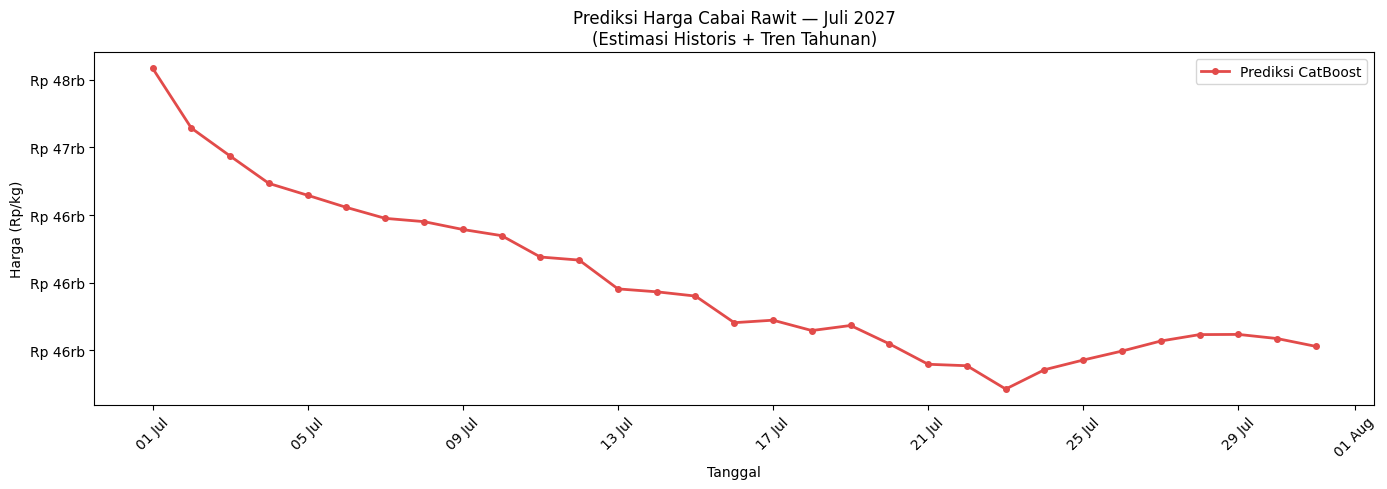

Rata-rata  : Rp 45,997/kg
Minimum    : Rp 45,215/kg
Maksimum   : Rp 47,584/kg


In [25]:
nama_bulan = f'{NAMA_BULAN[bulan]} {tahun}'
p = df_iklim['Prediksi']

plt.figure(figsize=(14, 5))
plt.plot(df_iklim['Tanggal'], p, color='#E24B4A', linewidth=2,
         marker='o', markersize=4, label='Prediksi CatBoost', zorder=3)

aktual_tgl = [pd.Timestamp(date(tahun, bulan, d))
              for d in range(1, last_day+1) if date(tahun, bulan, d) in aktual_dict]
if aktual_tgl:
    plt.plot(aktual_tgl, [aktual_dict[t.date()] for t in aktual_tgl],
             color='#1D9E75', linewidth=2, marker='s', markersize=5,
             label='Harga Aktual', zorder=4)

judul = f'Prediksi Harga Cabai Rawit — {nama_bulan}'
if SUMBER != 'API Real (Open-Meteo)':
    judul += f'\n({SUMBER})'

plt.title(judul)
plt.xlabel('Tanggal'); plt.ylabel('Harga (Rp/kg)')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}rb'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Rata-rata  : Rp {p.mean():,.0f}/kg')
print(f'Minimum    : Rp {p.min():,.0f}/kg')
print(f'Maksimum   : Rp {p.max():,.0f}/kg')

### 8.3 Ringkasan Akurasi Model

In [26]:
mae_final  = mean_absolute_error(harga_test_aktual.values, y_pred)
rmse_final = np.sqrt(mean_squared_error(harga_test_aktual.values, y_pred))
r2_final   = r2_score(harga_test_aktual.values, y_pred)
mape_final = mean_absolute_percentage_error(harga_test_aktual.values, y_pred) * 100

print(f'MAE  : Rp {mae_final:,.0f}/kg')
print(f'RMSE : Rp {rmse_final:,.0f}/kg')
print(f'R²   : {r2_final:.4f}')
print(f'MAPE : {mape_final:.2f}%')

MAE  : Rp 936/kg
RMSE : Rp 3,448/kg
R²   : 0.9722
MAPE : 1.65%
